<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

# Análisis y Procesamiento de Señales
## Trabajo Semanal Nº 1: Síntesis y operaciones de señales 
**Autor:** Federico Pieri  
**Institución:** Escuela de Ciencia y Tecnología — Universidad Nacional de San Martín (UNSAM)

---

### 1. Objetivos del Trabajo Práctico
* Sintetizar secuencias discretas de señales determinísticas (senoidales, pulsos rectangulares, ondas periódicas) y procesos estocásticos (ruido segun distribución normal y uniforme).
* Evaluar la distribución estadística de secuencias aleatorias mediante histogramas 

In [5]:
import gen_fun as gen
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parametros pedidos en el enunciado

N = 1000       # Cantidad total de muestras
f = 2000      # Frecuencia de la señal (2 KHz)
fs = 25000    # Frecuencia de muestreo

--- 
## 1) Señal Sinusoidal de 2 kHz 

### Marco Teórico
En la consigna se pide que la señal senoidal tenga **al menos 10 puntos por período** ($N_{per} \ge 10$):
$$N_{per} = \frac{F_s}{f} \ge 10 \implies F_s \ge 10 \cdot 2000\text{ Hz} = 20\text{ kHz}$$
Elegí una frecuencia de 25KHz para que la señal entre una cantidad entera de períodos en la ventana de 1000 muestras ya que si no ocurre esto se genera una discontinuidad (artificial) que produce un espectro incorrecto.
$$k = \frac{f \cdot N}{f_s} = \frac{2KHz \cdot 1000}{25KHz} = 80  $$

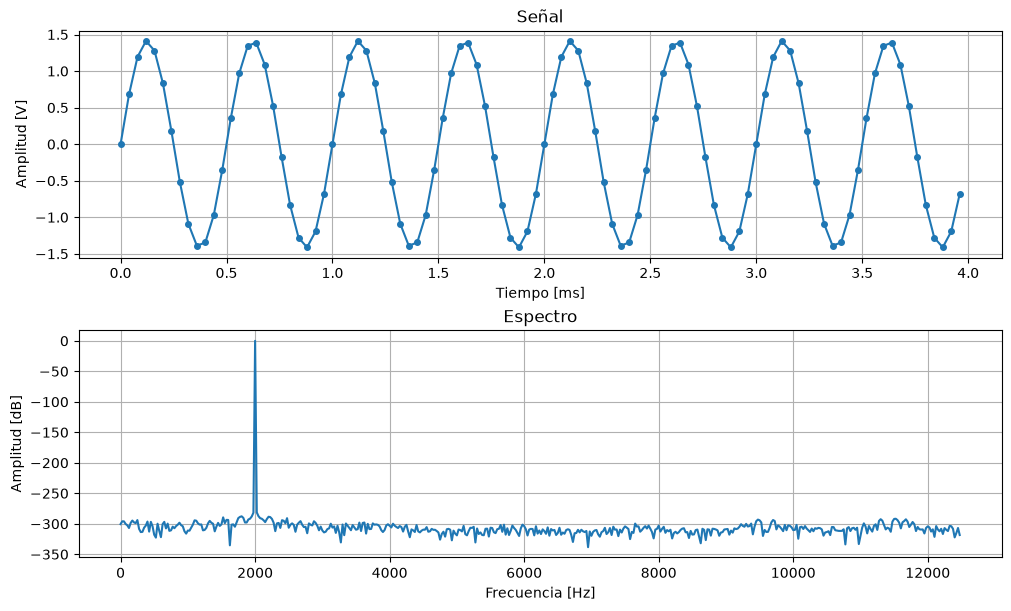

In [8]:
# ----------------------------------------------Codigo

tt, xx = gen.senoidal(pot = 1,ff = f,fs = fs) 
frec = tt*(fs/N)
frec = frec[:int(N/2)]
X = 1/N * np.fft.fft(xx)
X_db = 10 * (np.log10((np.abs(X)**2)*2))

tt = tt[:100]               #--------Muestro solo 100 valores para que se pueda apreciar la forma de onda.
xx = xx[:100]
tt = (1/fs)*tt *1000        #--------Convierto a tiempo

fig, ax = plt.subplots(2, 1, figsize=(10, 6),layout="constrained")

ax[0].plot(tt,xx,'-o', markersize=4)
ax[0].grid()
ax[0].set_title("Señal")
ax[0].set_xlabel("Tiempo [ms]")
ax[0].set_ylabel("Amplitud [V]")

ax[1].plot(frec,X_db[:int(N/2)])
ax[1].grid()
ax[1].set_title("Espectro")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Amplitud [dB]");


--- 
## 2: Señal de Potencia Media 2 W y Desfasada en $\pi/2$

### Marco Teórico
La potencia media de una señal periódica pura de forma $x(t) = A \sin(2\pi f_0 t + \phi)$ es:
$$P = \frac{A^2}{2} \implies A = \sqrt{2P} = \sqrt{2 \cdot 2\text{ W}} = 2\text{ V}$$

Un adelanto de fase $\phi = \pi/2$ transforma la función seno en una componente cosenoidal pura:
$$x(t) = 2 \sin(2\pi f_0 t + \pi/2) = 2 \cos(2\pi f_0 t)$$

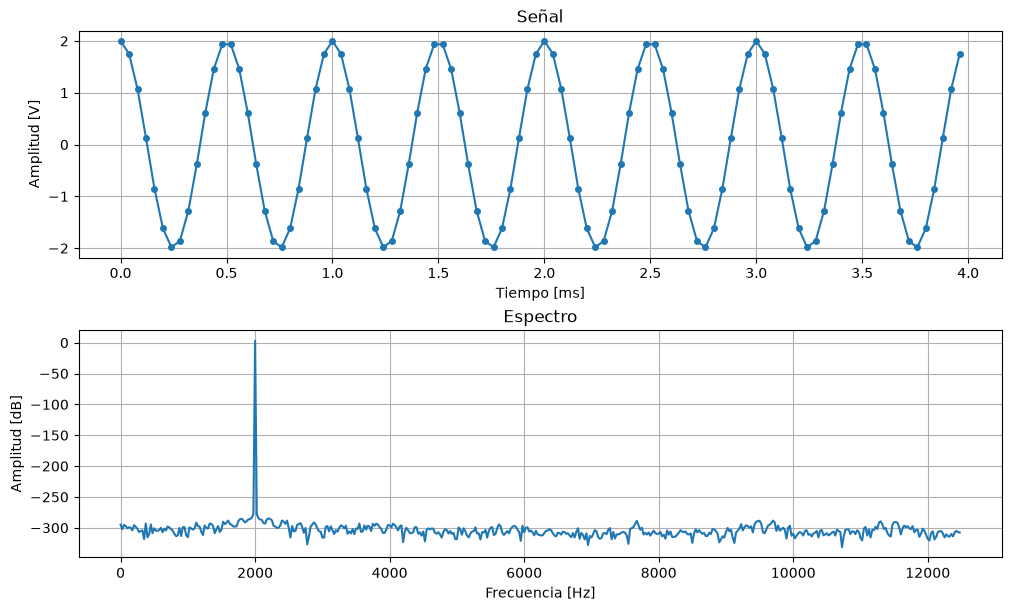

In [9]:
# ----------------------------------------------Codigo

tt, xx = gen.senoidal(pot = 2,ff = f,fs = fs,ph=np.pi/2) 
frec = tt*(fs/N)
frec = frec[:int(N/2)]
X = 1/N * np.fft.fft(xx)
X_db = 10 * (np.log10((np.abs(X)**2)*2))

tt = tt[:100]               #--------Muestro solo 100 valores para que se pueda apreciar la forma de onda.
xx = xx[:100]
tt = (1/fs)*tt *1000        #--------Convierto a tiempo

fig, ax = plt.subplots(2, 1, figsize=(10, 6),layout="constrained")

ax[0].plot(tt,xx,'-o', markersize=4)
ax[0].grid()
ax[0].set_title("Señal")
ax[0].set_xlabel("Tiempo [ms]")
ax[0].set_ylabel("Amplitud [V]")

ax[1].plot(frec,X_db[:int(N/2)])
ax[1].grid()
ax[1].set_title("Espectro")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Amplitud [dB]");

--- 
## 3 y 4: Ruido Gaussiano y Ruido Uniforme

### Marco Teórico
Para una variable aleatoria de media nula (sin componente de continua $\mu = 0\text{ V}$), la potencia media equivale a su varianza: $P = \sigma^2 = 0.1\text{ W}$.

* **Ruido Gaussiano:**
  $$X \sim \mathcal{N}(\mu = 0, \sigma^2 = 0.1) \implies \sigma = \sqrt{0.1} \approx 0.3162\text{ V}$$
* **Ruido Uniforme:**
  Definido en el intervalo simétrico $[-a, a]$, su varianza teórica es:
  $$\sigma^2 = \frac{(2a)^2}{12} = \frac{a^2}{3} = 0.1 \implies a = \sqrt{3 \cdot 0.1} = \sqrt{0.3} \approx 0.5477\text{ V}$$

En ambos casos se evalúa la señal temporal, el histograma comparado con su densidad de probabilidad analítica, y el módulo de la FFT.

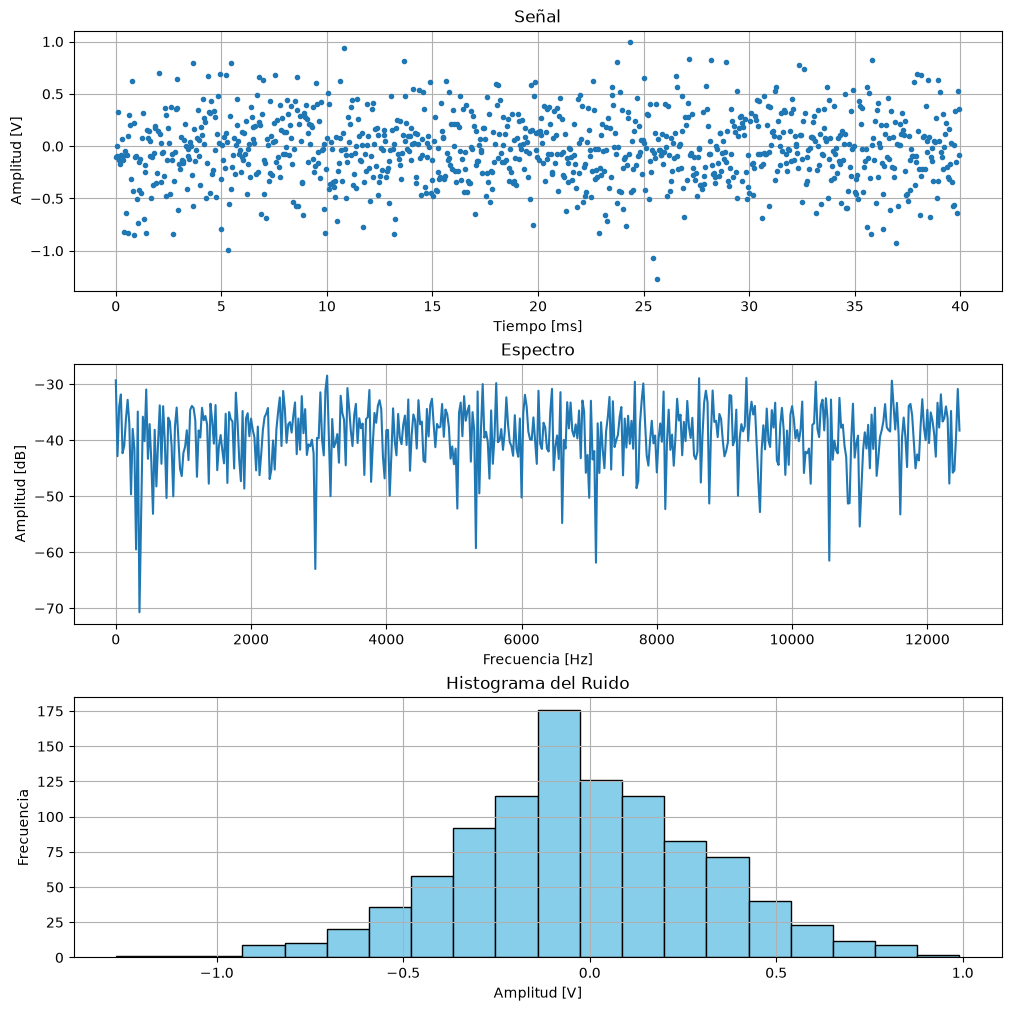

In [10]:
# ----------------------------------------------Codigo

tt, xx = gen.ruido_normal(pot=0.1,nn = N,fs = fs)
frec = tt*(fs/N)
frec = frec[:int(N/2)]
X = 1/N * np.fft.fft(xx)
X_db = 10 * (np.log10((np.abs(X)**2)*2))

tt = (1/fs)*tt *1000        #--------Convierto a tiempo

fig, ax = plt.subplots(3, 1, figsize=(10, 10),layout="constrained")

ax[0].plot(tt,xx,'.', markersize=6)
ax[0].grid()
ax[0].set_title("Señal")
ax[0].set_xlabel("Tiempo [ms]")
ax[0].set_ylabel("Amplitud [V]")

ax[1].plot(frec,X_db[:int(N/2)])
ax[1].grid()
ax[1].set_title("Espectro")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Amplitud [dB]");

ax[2].hist(xx, bins=20, edgecolor='black', color='skyblue')
ax[2].grid()
ax[2].set_title("Histograma del Ruido")
ax[2].set_xlabel("Amplitud [V]")
ax[2].set_ylabel("Frecuencia")

plt.show()

**Distribución en amplitud vs. distribución en frecuencia:** Por medio de estos gráficos podemos ver que en el dominio de la amplitud el ruido gaussiano concentra valores según la campana y tiene colas infinitas, mientras que el uniforme está acotado estrictamente entre $\pm 0.548\text{ V}$ y **sus espectros son indistinguibles a simple vista**.

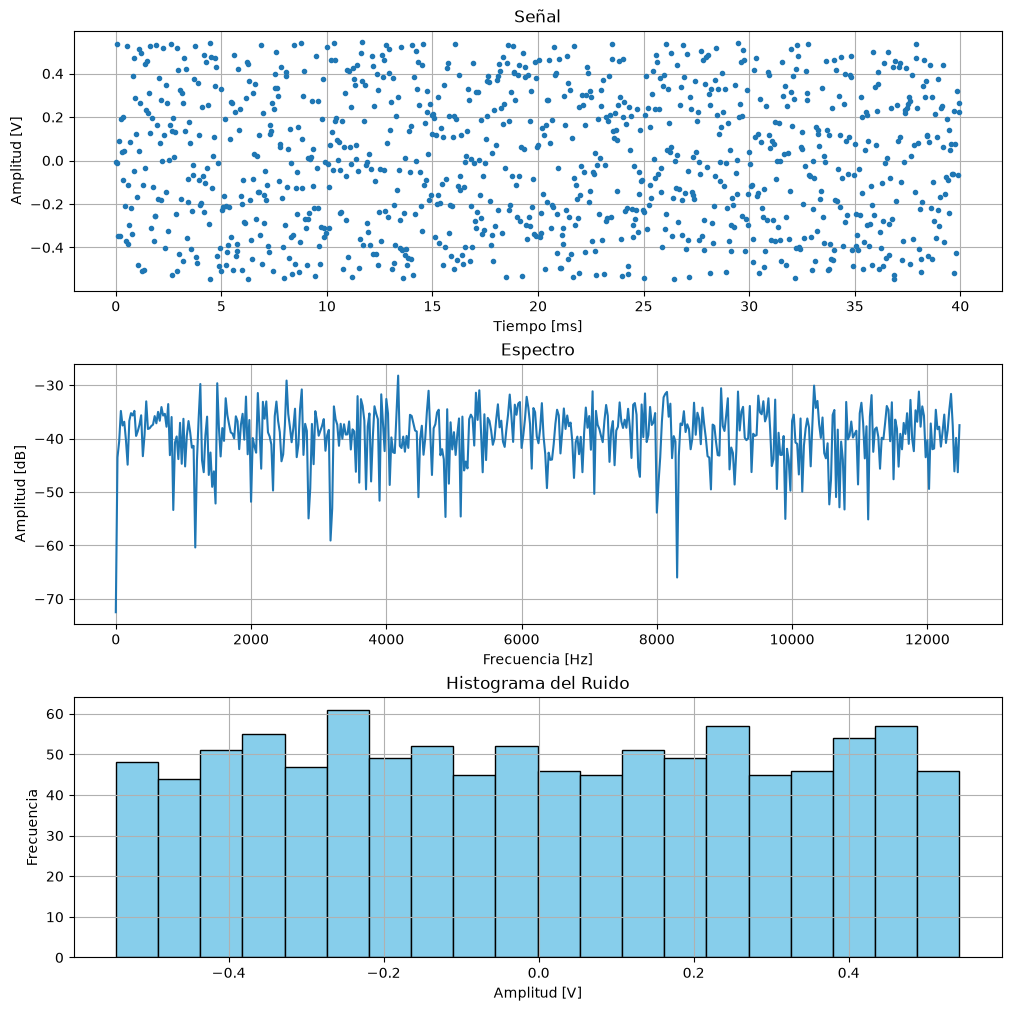

In [11]:
# ----------------------------------------------Codigo

tt, xx = gen.ruido_uniforme(pot=0.1,nn = N,fs = fs)
frec = tt*(fs/N)
frec = frec[:int(N/2)]
X = 1/N * np.fft.fft(xx)
X_db = 10 * (np.log10((np.abs(X)**2)*2))

tt = (1/fs)*tt *1000        #--------Convierto a tiempo

fig, ax = plt.subplots(3, 1, figsize=(10, 10),layout="constrained")

ax[0].plot(tt,xx,'.', markersize=6)
ax[0].grid()
ax[0].set_title("Señal")
ax[0].set_xlabel("Tiempo [ms]")
ax[0].set_ylabel("Amplitud [V]")

ax[1].plot(frec,X_db[:int(N/2)])
ax[1].grid()
ax[1].set_title("Espectro")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Amplitud [dB]");

ax[2].hist(xx, bins=20, edgecolor='black', color='skyblue')
ax[2].grid()
ax[2].set_title("Histograma del Ruido")
ax[2].set_xlabel("Amplitud [V]")
ax[2].set_ylabel("Frecuencia")

plt.show()

--- 
## 4) Pulso Rectangular Periódico (Onda Cuadrada)

### Marco Teórico
Se sintetiza una onda periódica cuadrada bipolar de ciclo de trabajo del 50% con valores en $\pm A$.
Su potencia media es constante e independiente del tiempo:
$$P = \frac{1}{T} \int_{0}^{T} x^2(t) dt = A^2 = 1\text{ W} \implies A = \sqrt{1\text{ W}} = 1\text{ V}$$



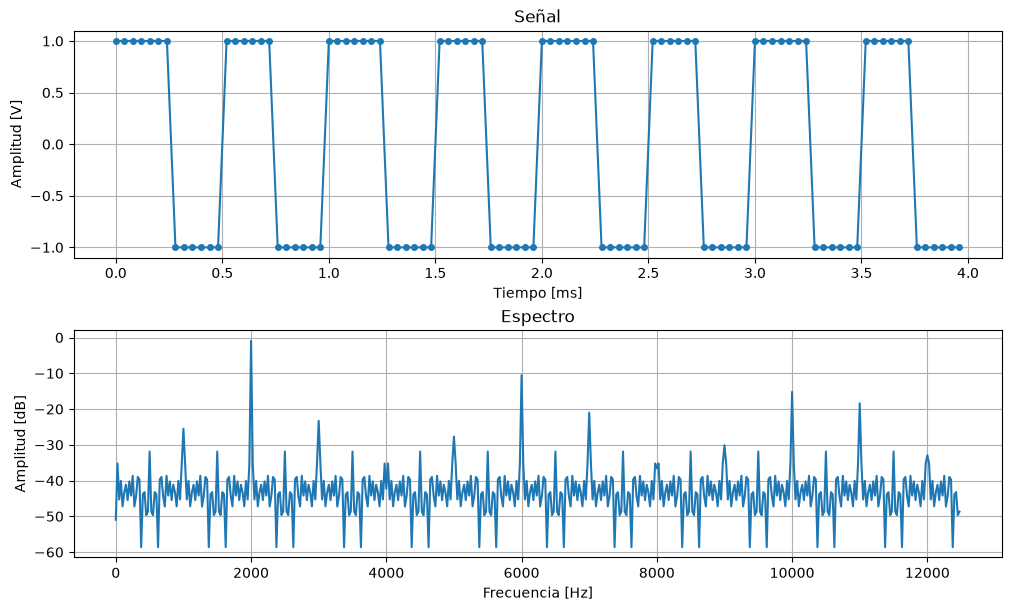

In [12]:
# ----------------------------------------------Codigo

tt, xx = gen.cuadrada_duty(pot = 1,duty = 50,fs = fs, ff = f,nn = N)
frec = tt*(fs/N)
frec = frec[:int(N/2)]
X = 1/N * np.fft.fft(xx)
X_db = 10 * (np.log10((np.abs(X)**2)*2))

tt = tt[:100]               #--------Muestro solo 100 valores para que se pueda apreciar la forma de onda.
xx = xx[:100]
tt = (1/fs)*tt *1000        #--------Convierto a tiempo

fig, ax = plt.subplots(2, 1, figsize=(10, 6),layout="constrained")

ax[0].plot(tt,xx,'-o', markersize=4)
ax[0].grid()
ax[0].set_title("Señal")
ax[0].set_xlabel("Tiempo [ms]")
ax[0].set_ylabel("Amplitud [V]")

ax[1].plot(frec,X_db[:int(N/2)])
ax[1].grid()
ax[1].set_title("Espectro")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Amplitud [dB]");

--- 
## Bonus: Onda Triangular Adicional y Calculo de potencia con teorema de parseval

### Marco Teórico del Teorema de Parseval
Para una señal discreta $x[n]$ y su Transformada Discreta de Fourier normalizada $X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}$, la potencia media en ambos dominios satisface estrictamente la igualdad:
$$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \sum_{k=0}^{N-1} |X[k]|^2$$

Luego se implementó una señal triangular utilizando la función **scipy.signal.sawtooth**

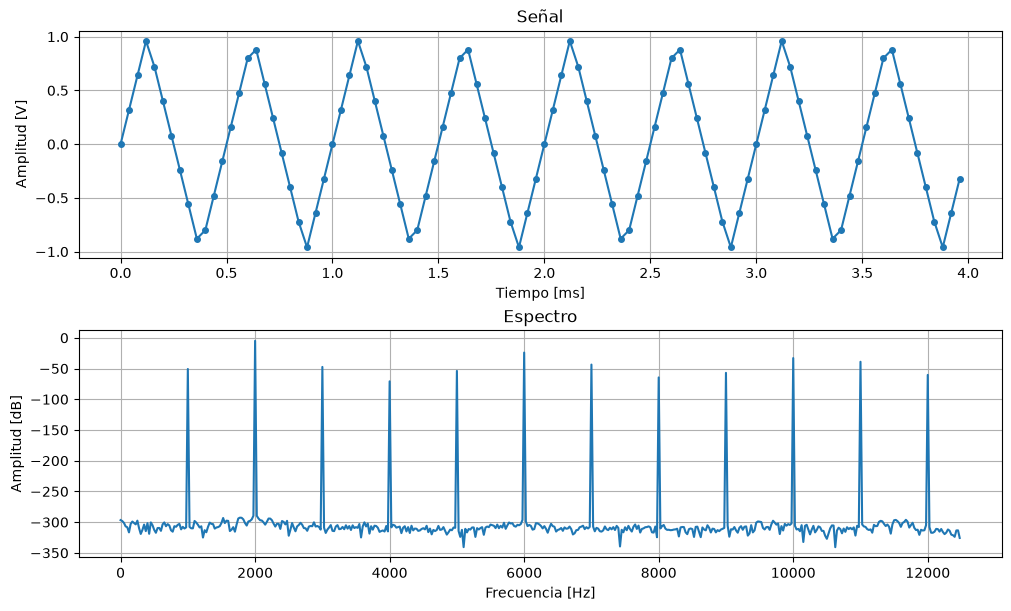

In [6]:
# ----------------------------------------------Codigo

tt, xx = gen.triangular(pot = 1,ff = f,fs = fs) 
frec = tt*(fs/N)
frec = frec[:int(N/2)]
X = 1/N * np.fft.fft(xx)
X_db = 10 * (np.log10((np.abs(X)**2)*2))

tt = tt[:100]               #--------Muestro solo 100 valores para que se pueda apreciar la forma de onda.
xx = xx[:100]
tt = (1/fs)*tt *1000        #--------Convierto a tiempo

fig, ax = plt.subplots(2, 1, figsize=(10, 6),layout="constrained")

ax[0].plot(tt,xx,'-o', markersize=4)
ax[0].grid()
ax[0].set_title("Señal")
ax[0].set_xlabel("Tiempo [ms]")
ax[0].set_ylabel("Amplitud [V]")

ax[1].plot(frec,X_db[:int(N/2)])
ax[1].grid()
ax[1].set_title("Espectro")
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].set_ylabel("Amplitud [dB]");

In [15]:
# ----------------------------------------------Codigo
tt, xx = gen.senoidal(pot = 12.4,ff = f,fs = fs) 
X = 1/N * np.fft.fft(xx)
pot_tiempo = np.mean((np.abs(xx)**2))
pot_frec = np.sum((np.abs(X)**2))
print("Potencia calculada en base al tiempo:",pot_tiempo,"W")
print("Potencia calculada en base a la frecuencia:",pot_frec,"W")



Potencia calculada en base al tiempo: 12.39999999999999 W
Potencia calculada en base a la frecuencia: 12.399999999999991 W
